## Problema del viajero

Suponga que un viajante tiene que visitar n ciudades en el menor tiempo posible. Considere una matriz D de tamaño $n \times n$ cuyos elementos $d_{pq}$ denotan la distancia entre cada par de ciudades (p, q). Se define un recorrido como una trayectoria cerrada que **visita cada ciudad una y sólo una vez** (a excepción de la ciudad de partida, a la cual debe regresar). El problema consiste en **hallar el recorrido de mı́nima longitud.**

Implemente el algoritmo de sistema de hormigas y utilı́celo para resolver el problema del agente viajero considerando los datos proporcionados en el archivo gr17.csv


In [5]:
def calcular_long(x,E):
    cam = np.array(x)
    dist = 0
    for i in range(len(cam)-1):
        dist += E[cam[i],cam[i+1]]
    
    return dist

In [ ]:
import numpy as np
import pandas as pd
import time
import networkx as nx 


def sistemaHormigas(rho=0.1, maxIter=500, Q=1, tipo_deposito=1):
    E = pd.read_csv("gr17.csv",header=None).to_numpy()

    N = 10
    sigma = np.random.random(E.shape)
    it = 0

    p = {}
    mejor_dist = np.inf
    mejor_cam = []

    while True:
        dist_cam = {}
        for k in range(N):
            p[k] = [np.random.randint(0,E.shape[1])]
            ciudades_x_visitar = np.ones(E.shape[0])
            ciudades_x_visitar[p[k][0]] = 0
            
            while (ciudades_x_visitar == 1).any():  # iterar hasta que no haya ciudades por visitar
                prob = np.zeros(E.shape[0])

                i = p[k][-1]    # pararse en la ciudad en la que quedó la hormiga
                suma = 0
                # calculo de la probabilidad
                for u in range(len(ciudades_x_visitar)):
                    if ciudades_x_visitar[u]==1:
                        suma += sigma[i,u]* ( 1/E[i,u])
                
                for j in range(len(ciudades_x_visitar)):
                    if ciudades_x_visitar[j]==1:
                        prob[j] = sigma[i,j]* ( 1/E[i,j]) / suma

                prob_elegir = np.random.random()
                ind_elegir = -1
                suma_prob = 0
                for j in range(len(prob)):
                    if(prob[j] != 0):
                        suma_prob += prob[j]
                        ind_elegir = j
                        if (suma_prob >= prob_elegir):
                            break

                p[k].append(ind_elegir)
                ciudades_x_visitar[ind_elegir] = 0

            p[k].append(p[k][0])
            dist_cam[k] = calcular_long(p[k],E)
            if dist_cam[k] < mejor_dist:
                mejor_dist = dist_cam[k]
                mejor_cam = p[k].copy()


        # verificar si todos los caminos elegidos son iguales
        k_1 = p[0]
        iguales = True
        for k in range(1,N):
            if p[k] != k_1:
                iguales = False
                break

        if iguales or it >= maxIter: break 

        # para cada conexion (i,j):
        # reducir por evaporacion las feromonas
        for i in range(sigma.shape[0]):
            for j in range(sigma.shape[1]):
                sigma[i,j] = (1-rho)*sigma[i,j]

        # depositar feromonas
        for k in range(N):
            if tipo_deposito == 1:
                delta_sigma_k = Q/dist_cam[k]
            elif tipo_deposito == 2:
                delta_sigma_k = Q
            

            for idx in range(len(p[k])-1):
                i, j = p[k][idx], p[k][idx+1]
                if tipo_deposito == 3:
                    delta_sigma_k = Q/E[i,j]
                    
                sigma[i,j] += delta_sigma_k
                sigma[j,i] += delta_sigma_k

        it += 1


    return (it, mejor_cam, mejor_dist)


            

### Parte 2

Analice el efecto de la tasa de evaporación $(\rho)$ y de la cantidad de feromona depositada $(\tau)$ sobre los resultados de la búsqueda. Para esto último compare el desempeño del algoritmo empleando los *métodos global, local y uniforme* para depósito de feromonas. Realice varias corridas con cada configuración experimental y considere el tiempo de búsqueda y la longitud de los caminos encontrados como medidas para comparar el desempeño. Construya una tabla comparativa con los resultados obtenidos.


In [7]:

valores_rho = [0.1, 0.3, 0.5, 0.8] 
valores_tipo = [1, 2, 3]
max_iteraciones = 500

nombres_deposito = {1: 'Global', 2: 'Uniforme', 3: 'Local'}
resultados = []

for rho in valores_rho:
    for tipo in valores_tipo:
        print(f"Evaporación={rho}, Tipo depósito={nombres_deposito[tipo]}")

        t_0 = time.perf_counter()
        it, mejor_cam, mejor_dist = sistemaHormigas(rho=rho, maxIter=max_iteraciones, Q=1, tipo_deposito=tipo)
        t_fin = time.perf_counter()
        t_ejecucion = t_fin - t_0
        
        # Guardar los resultados como un diccionario
        resultados.append({
            'Rho (Evaporación)': rho,
            'Tipo de Depósito': nombres_deposito[tipo],
            'Mejor distancia': mejor_dist,
            'Tiempo de ejecución [s]': round(t_ejecucion,3),
            'Iteración final': it,
            'Camino': str(mejor_cam)
        })
    print("\n")


tabla = pd.DataFrame(resultados)    # formatear los resultados como una tabla
tabla_ordenada = tabla.sort_values(by='Mejor distancia', ascending=True)    # ordenar por valor de costo en distancia

display(tabla_ordenada)


Evaporación=0.1, Tipo depósito=Global
Evaporación=0.1, Tipo depósito=Uniforme
Evaporación=0.1, Tipo depósito=Local


Evaporación=0.3, Tipo depósito=Global
Evaporación=0.3, Tipo depósito=Uniforme
Evaporación=0.3, Tipo depósito=Local


Evaporación=0.5, Tipo depósito=Global
Evaporación=0.5, Tipo depósito=Uniforme
Evaporación=0.5, Tipo depósito=Local


Evaporación=0.8, Tipo depósito=Global
Evaporación=0.8, Tipo depósito=Uniforme
Evaporación=0.8, Tipo depósito=Local




,Rho (Evaporación),Tipo de Depósito,Mejor distancia,Tiempo de ejecución [s],Iteración final,Camino
0,0.1,Global,2085,2.078,500,"[15, 0, 3, 12, 6, 7, 5, 16, 13, 14, 2, 10, 9, ..."
1,0.1,Uniforme,2085,1.826,500,"[2, 14, 13, 16, 5, 7, 6, 12, 3, 0, 15, 11, 8, ..."
2,0.1,Local,2085,1.936,500,"[10, 2, 14, 13, 16, 5, 7, 6, 12, 3, 0, 15, 11,..."
3,0.3,Global,2085,1.916,500,"[11, 15, 0, 3, 12, 6, 7, 5, 16, 13, 14, 2, 10,..."
5,0.3,Local,2085,1.969,500,"[16, 5, 7, 6, 12, 3, 0, 15, 11, 8, 4, 1, 9, 10..."
7,0.5,Uniforme,2085,1.856,500,"[6, 7, 5, 16, 13, 14, 2, 10, 9, 1, 4, 8, 11, 1..."
8,0.5,Local,2085,1.849,500,"[4, 1, 9, 10, 2, 14, 13, 16, 5, 7, 6, 12, 3, 0..."
4,0.3,Uniforme,2088,2.200,500,"[1, 9, 10, 2, 14, 13, 16, 5, 7, 6, 0, 12, 3, 1..."
10,0.8,Uniforme,2088,1.815,500,"[6, 7, 5, 16, 13, 14, 2, 10, 9, 1, 4, 8, 11, 1..."
11,0.8,Local,2094,1.979,500,"[4, 1, 9, 10, 2, 14, 13, 16, 5, 7, 6, 3, 12, 0..."


### Gráfica de conexiones y mejor camino encontrado


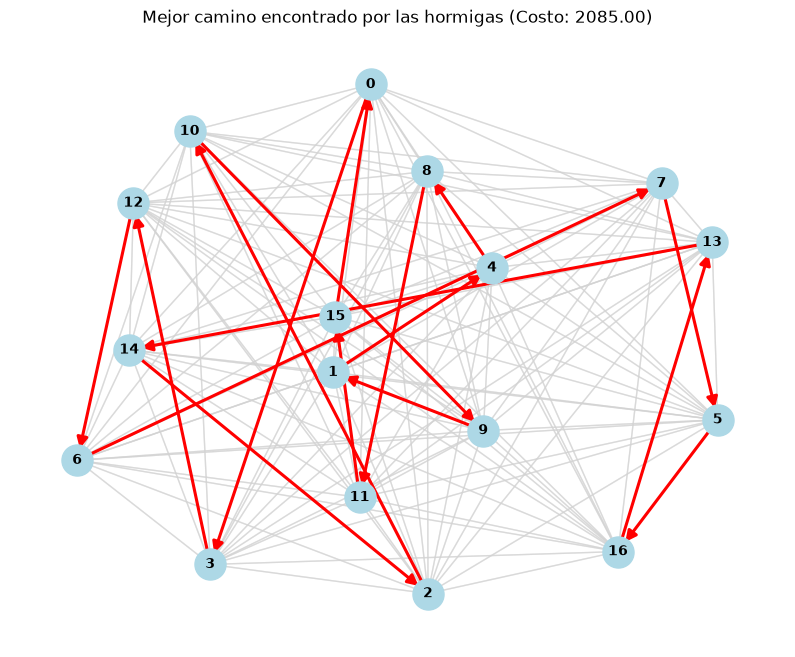

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv("gr17.csv", header=None)

# Crear el grafo a partir del df
G = nx.from_pandas_adjacency(df, create_using=nx.DiGraph()) # DiGraph para que sea direccional y poder ver las flechas
G.remove_edges_from(nx.selfloop_edges(G))

it, mejor_cam, mejor_dist = sistemaHormigas(rho=0.1, Q=1, tipo_deposito=1)  # Probar según el mejor que salió en la tabla anterior

camino_grafo = [(mejor_cam[i], mejor_cam[i+1]) for i in range(len(mejor_cam) - 1)]  # Armar tupla de conexiones (i, j)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)  # Algoritmo para separar los nodos

# Dibujar grafo: nodos, aristas y camino recorrido
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='lightgray', alpha=0.6, arrows=False)
# Resaltar únicamente las aristas que forman parte del mejor camino encontrado
nx.draw_networkx_edges(G, pos, edgelist=camino_grafo, edge_color='red', width=2.2, arrows=True, arrowsize=16)

plt.title(f"Mejor camino encontrado por las hormigas (Costo: {mejor_dist:.2f})")
plt.axis('off')
plt.show()
